In [1]:
from pathlib import Path

import pandas as pd
from datasets import DatasetDict, Image, load_dataset
from huggingface_hub import hf_hub_download

/Users/ashapatel/Documents/projects/fake-image-detection/vit_pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


I downloaded a single shard of the training data to open and inspect.

See https://huggingface.co/datasets/ComplexDataLab/OpenFake

In [8]:
train_shard0 = pd.read_parquet("../data/train-00000-of-00032-00000.parquet", engine="pyarrow")

In [9]:
train_shard0

,image,prompt,label,model,type,release_date
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,NaN,fake,flux.2-dev,Base,2025-11-22
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"A photograph of Richard Griffiths, a man with ...",real,laion,real,2021-08
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"A very cute gingerbread fox with large, shiny ...",fake,imagen-4.0,image,2026-01
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"A stylized poster for ""Pulp Fiction,"" featurin...",real,laion,real,2021-08
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,NaN,real,pexels,real,2020-12
...,...,...,...,...,...,...
3995,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,A photograph captures a couple dressed in wedd...,real,laion,base,2021-08
3996,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,NaN,real,pexels,real,2023-08
3997,{'bytes': b'\xff\xd8\xff\xe1\x00\xbcExif\x00\x...,A photograph of a person wearing a black hoodi...,real,laion,base,2021-08
3998,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,NaN,real,pexels,real,2023-10


Loading the parquet file into a dataframe, we can see there are 6 columns and 4000 rows, with each row corresponding to an image.

The columns are:
- image (bytes)

- prompt: the prompt used to generate the image, or for real images this is just a caption
- label: 'real' or 'fake'
- model: for fake images this is the generator name e.g 'flux.2-dev', and for real images this is the name of the dataset the image comes from e.g 'laion'
- type: generator class: base, finetune, lora, image (for non-generator real photos), video (for frames extracted from text-to-video / image-to-video models).
- release_date: first release date of the generator, or collection date for real images. Format varies (YYYY-MM or YYYY-MM-DD).

In [46]:
# Data correction: all 227 'sd-2.1' rows are tagged release_date "2024-01", but
# Stable Diffusion 2.1 was actually released in December 2022.
train_shard0.loc[train_shard0["model"] == "sd-2.1", "release_date"] = "2022-12"

### Feature distributions

In [10]:
train_shard0["label"].value_counts()

label
real    2032
fake    1968
Name: count, dtype: int64

In [50]:
import matplotlib.pyplot as plt

# Fixed, colorblind-safe categorical order (never cycled/rainbow).
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
OTHER_COLOR = "#9c9c9c"


def plot_pie(counts: pd.Series, title: str, top_n: int = 7) -> None:
    """Pie chart from a value_counts series, folding anything past top_n into 'Other'.

    Category names go in a legend rather than on the wedges, so labels for
    similarly-sized slices don't overlap; only the percentage stays on the wedge.
    """
    if len(counts) > top_n:
        counts = pd.concat([counts.iloc[:top_n], pd.Series({"Other": counts.iloc[top_n:].sum()})])
    colors = CATEGORICAL[: len(counts)]
    if "Other" in counts.index:
        colors[-1] = OTHER_COLOR
    plt.figure(figsize=(6, 5))
    wedges, _, _ = plt.pie(counts, autopct="%1.0f%%", colors=colors, startangle=90, pctdistance=0.8)
    plt.legend(wedges, counts.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [35]:
train_shard0["label"].value_counts()

label
real    2032
fake    1968
Name: count, dtype: int64

In [61]:
train_shard0[train_shard0["label"] == "fake"]["model"].value_counts()

model
sd-3.5                      258
sd-2.1                      227
flux.1-dev                  179
midjourney-6                 92
sdxl-epic-realism            87
                           ... 
sdxl-1.0                      1
noobai                        1
hunyuan-video                 1
seedream-v4.5                 1
amateur-photography-v2.0      1
Name: count, Length: 74, dtype: int64

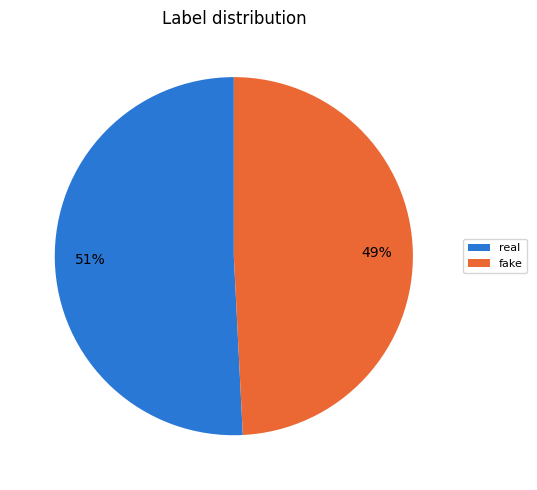

In [51]:
plot_pie(train_shard0["label"].value_counts(), "Label distribution")

We have roughly 2000 images in each of the 'fake' and 'real' subsets.

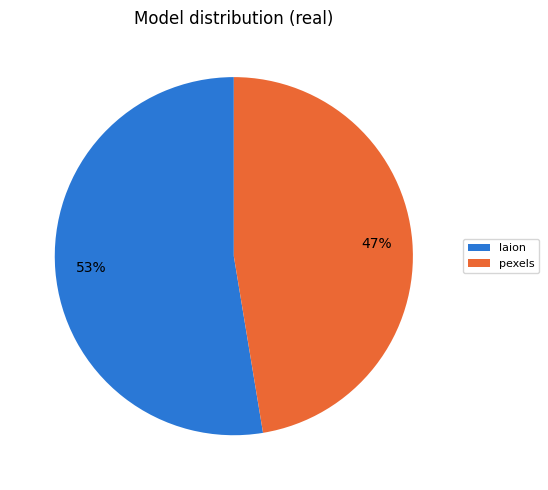

In [52]:
counts = train_shard0.loc[train_shard0["label"] == 'real', "model"].value_counts()
plot_pie(counts[counts > 1], f"Model distribution (real)", top_n = 20)

The real images come from the 'laion' and 'pexels' dataset, nearly 50/50.

The huggingface dataset source states that 'laion' contains 'politically salient or newsworthy images' and 'carries authentic web compression artifacts'.

The 'pexels' dataset is described as 'high-quality stock photographs'.

In [53]:
fake = train_shard0[train_shard0["label"] == "fake"]
fake_counts = fake["model"].value_counts()
fake_counts = fake_counts[fake_counts > 10].sort_values()

# A few models have a handful of rows tagged with a stray off-year; take the mode
# so each model gets a single representative release year.
model_year = fake.groupby("model")["release_date"].agg(lambda s: s.str[:4].mode()[0])
labels = [f"{model} ({model_year[model]})" for model in fake_counts.index]

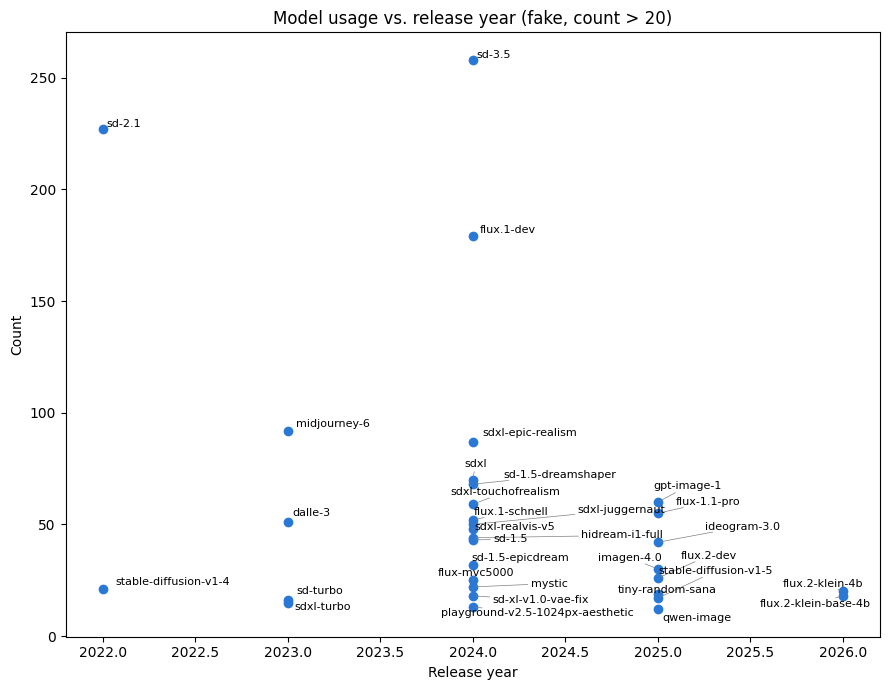

In [54]:
# Same models/counts as the bar chart above, but year is a real axis instead of label text.
from adjustText import adjust_text

plt.figure(figsize=(9, 7))
years = model_year.loc[fake_counts.index].astype(int)
plt.scatter(years, fake_counts.values, color=CATEGORICAL[0])
texts = [
    plt.annotate(model, (year, count), fontsize=8)
    for model, year, count in zip(fake_counts.index, years, fake_counts.values)
]
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
plt.xlabel("Release year")
plt.ylabel("Count")
plt.title("Model usage vs. release year (fake, count > 20)")
plt.tight_layout()
plt.show()

This scatter plot shows that the majority of the fake images were generated by models released in 2024, e.g stable diffusion 3.5 and flux.1-dev. The former is the most significant contributor, with ~250 images, followed by stable diffusion 2.1, with ~225, which was released in 2022. The majority of models contribute between 20 and 70 fake images to the dataset.

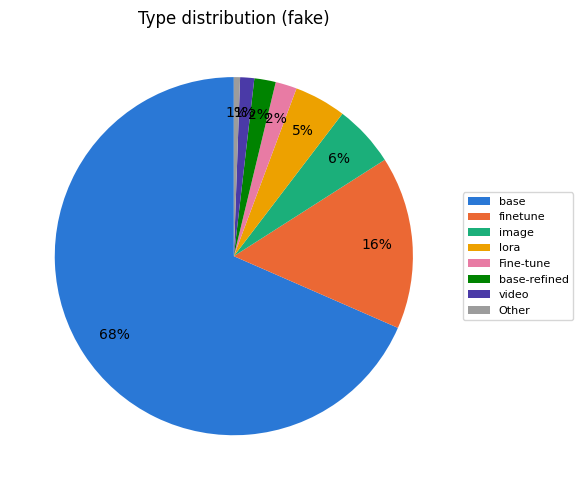

In [55]:
fake_type = train_shard0.loc[train_shard0["label"] == "fake", "type"].replace({"Base": "base"})
plot_pie(fake_type.value_counts(), "Type distribution (fake)")

68% of the fake images come from base models, which presumably overlaps with the 'frontier proprietary models' and 'open source flagships' categories listed on the huggingface dataset website. The other 32%, which include 'finetune' and 'lora', presumably overlap with the 'community fine-tunes and LoRAs (sampled from Civitai)' category.